# 04 Exploratory Data Analysis (EDA)
**Project:** Retailmart Finance Analytics  
**Phase:** Understand distribution of sales, customer behaviors, transactions, and store demographics.

---

### 1. Setup & Imports
We must add the parent directory to the system path so Python can locate the custom `src` modules.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Add root directory to python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom configurations and utilities
from src.config.config import config
from src.database.connection import db_connector
from src.utils.logger import setup_logger
from src.utils.helpers import save_dataframe

import matplotlib.pyplot as plt
import seaborn as sns

logger = setup_logger(os.path.splitext(os.path.basename('__file__'))[0])
logger.info('Notebook setup and imports loaded successfully.')

[2026-07-19 14:22:12] [INFO] [config.py:16] Loaded environment configuration from: E:\SQL ACCIO JOB\Cross functional dashboard\.env


[2026-07-19 14:22:13] [INFO] [connection.py:42] SQLAlchemy Database Engine initialized successfully.


[2026-07-19 14:22:14] [INFO] [632840764.py:19] Notebook setup and imports loaded successfully.


### 2. Load Cleaned Datasets
Placeholder for load cleaned datasets steps.

In [2]:
import glob
import os

# Find all cleaned CSV files in data/processed/
processed_files = glob.glob("../data/processed/*.csv")
print(f"Found {len(processed_files)} processed files for EDA:\n")

# Load them into a dictionary, parsing date columns automatically
dfs = {}
for file in processed_files:
    name = os.path.splitext(os.path.basename(file))[0]
    
    # Define which columns are dates for each dataset
    date_cols = []
    if name == "sales_transaction_orders":
        date_cols = ["order_date", "created_at"]
    elif name == "sales_transaction_payments":
        date_cols = ["payment_date"]
    elif name == "sales_transaction_invoices":
        date_cols = ["invoice_date"]
    elif name == "finance_accounting_ledger_entries":
        date_cols = ["transaction_date", "posted_at"]
    elif name == "finance_accounting_dealer_payouts":
        date_cols = ["payout_date"]
    
    dfs[name] = pd.read_csv(file, parse_dates=date_cols)
    print(f" - Loaded: {name} (Shape: {dfs[name].shape})")

Found 18 processed files for EDA:

 - Loaded: customer_customers (Shape: (5000, 19))
 - Loaded: dealer_dealers (Shape: (200, 16))
 - Loaded: dealer_network_dealer_commissions (Shape: (3000, 9))
 - Loaded: dealer_network_dealer_targets (Shape: (4800, 8))
 - Loaded: dealer_network_regional_offices (Shape: (20, 4))
 - Loaded: finance_accounting_dealer_payouts (Shape: (2500, 7))
 - Loaded: finance_accounting_gl_accounts (Shape: (80, 6))
 - Loaded: finance_accounting_ledger_entries (Shape: (15000, 10))
 - Loaded: finance_accounting_tax_records (Shape: (7000, 8))
 - Loaded: location_reference_cities (Shape: (200, 7))
 - Loaded: location_reference_states (Shape: (36, 6))
 - Loaded: pricing_management_price_master (Shape: (1440, 10))
 - Loaded: product_management_vehicle_models (Shape: (25, 9))
 - Loaded: product_management_vehicle_variants (Shape: (96, 11))
 - Loaded: sales_transaction_invoices (Shape: (7000, 14))


 - Loaded: sales_transaction_orders (Shape: (7000, 16))
 - Loaded: sales_transaction_order_items (Shape: (7500, 12))
 - Loaded: sales_transaction_payments (Shape: (8000, 11))


### 3. Univariate Analysis (Distributions)
Placeholder for univariate analysis (distributions) steps.

--- 1. NUMERICAL DISTRIBUTIONS ---


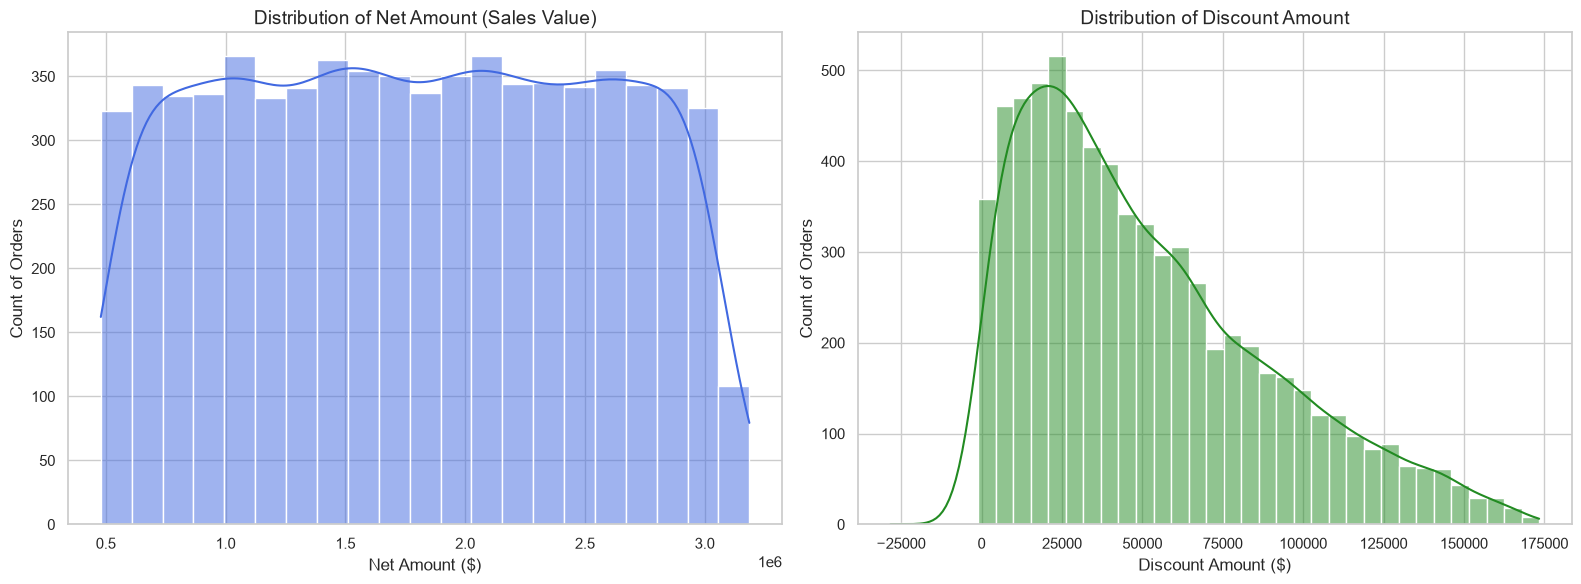


--- 2. CATEGORICAL DISTRIBUTIONS (Frequencies) ---


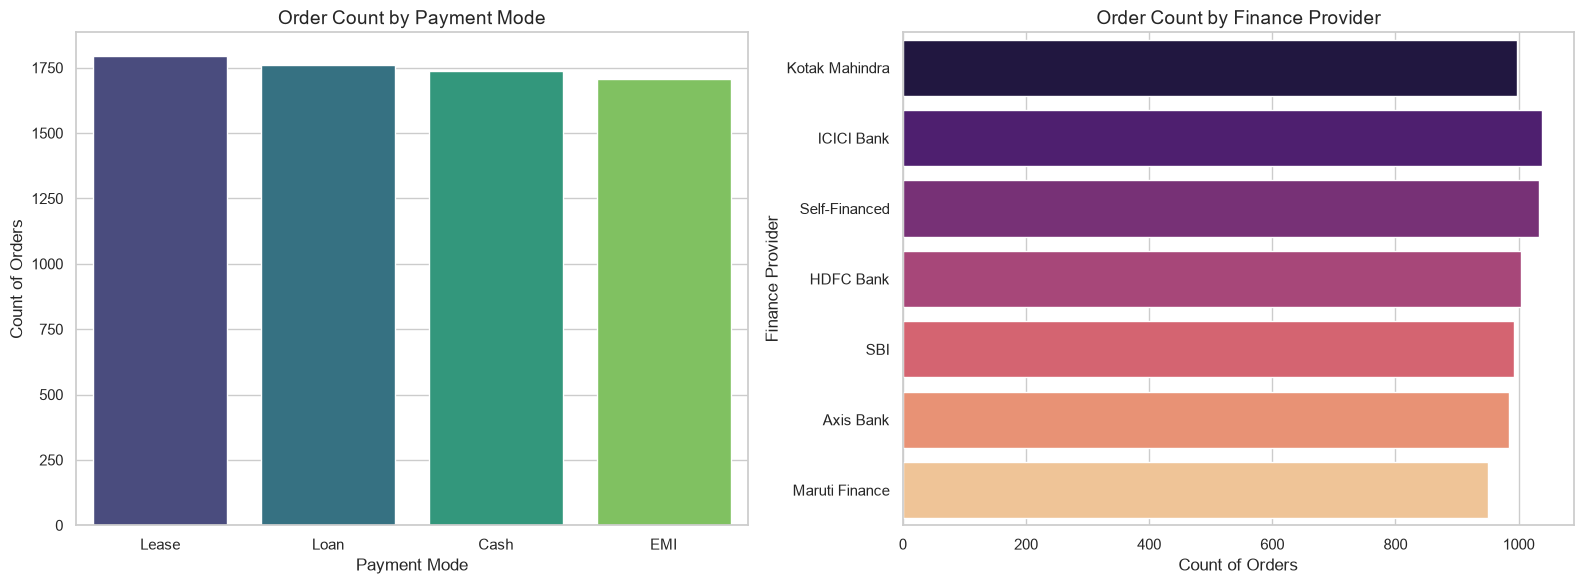

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional styling tokens for Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

orders_df = dfs.get("sales_transaction_orders")
if orders_df is not None:
    print("--- 1. NUMERICAL DISTRIBUTIONS ---")
    # Subplots for numerical sales figures
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Net amount histogram + KDE
    sns.histplot(data=orders_df, x="net_amount", kde=True, ax=axes[0], color="royalblue")
    axes[0].set_title("Distribution of Net Amount (Sales Value)", fontsize=14)
    axes[0].set_xlabel("Net Amount ($)", fontsize=12)
    axes[0].set_ylabel("Count of Orders", fontsize=12)
    
    # Discount amount histogram + KDE
    sns.histplot(data=orders_df, x="discount_amount", kde=True, ax=axes[1], color="forestgreen")
    axes[1].set_title("Distribution of Discount Amount", fontsize=14)
    axes[1].set_xlabel("Discount Amount ($)", fontsize=12)
    axes[1].set_ylabel("Count of Orders", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print("\n--- 2. CATEGORICAL DISTRIBUTIONS (Frequencies) ---")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart for payment modes
    sns.countplot(data=orders_df, x="payment_mode", ax=axes[0], palette="viridis", hue="payment_mode", legend=False)
    axes[0].set_title("Order Count by Payment Mode", fontsize=14)
    axes[0].set_xlabel("Payment Mode", fontsize=12)
    axes[0].set_ylabel("Count of Orders", fontsize=12)
    
    # Bar chart for finance providers
    sns.countplot(data=orders_df, y="finance_provider", ax=axes[1], palette="magma", hue="finance_provider", legend=False)
    axes[1].set_title("Order Count by Finance Provider", fontsize=14)
    axes[1].set_xlabel("Count of Orders", fontsize=12)
    axes[1].set_ylabel("Finance Provider", fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("Core orders dataset not found.")

### 4. Bivariate Analysis (Relationships)
Placeholder for bivariate analysis (relationships) steps.

--- 1. RELATIONSHIP: PAYMENT MODE vs NET AMOUNT ---


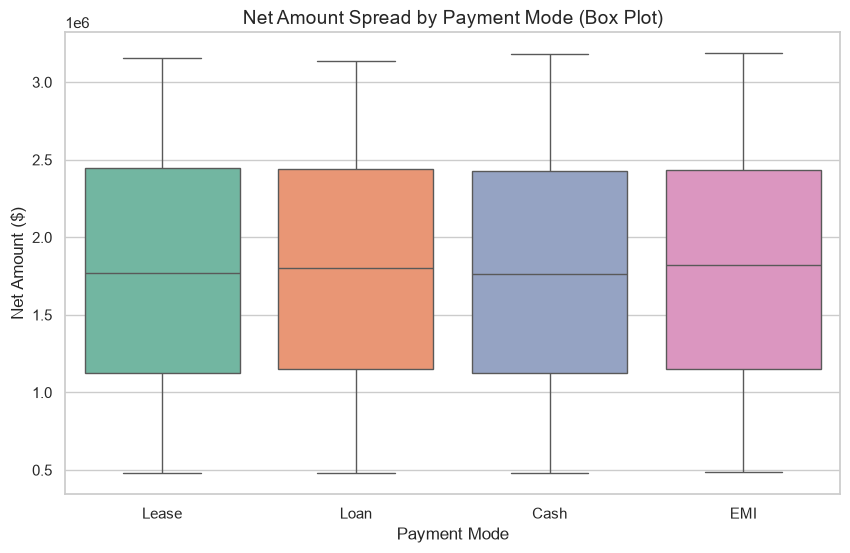


--- 2. TIME-SERIES: MONTHLY NET REVENUE TRENDS ---


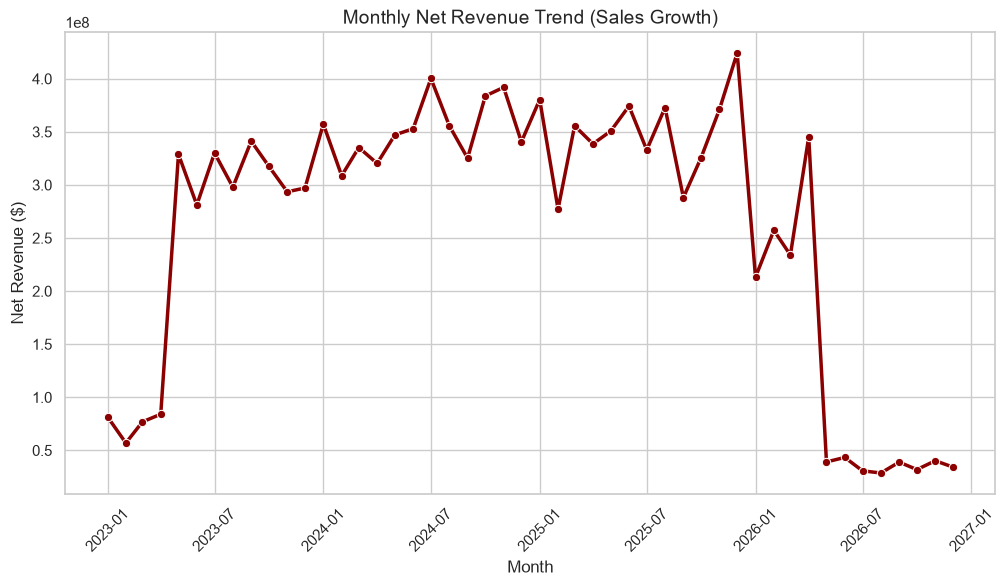

In [4]:
if orders_df is not None:
    print("--- 1. RELATIONSHIP: PAYMENT MODE vs NET AMOUNT ---")
    # Box plot to see spread of Sales Values across Payment Modes
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=orders_df, x="payment_mode", y="net_amount", palette="Set2", hue="payment_mode", legend=False)
    plt.title("Net Amount Spread by Payment Mode (Box Plot)", fontsize=14)
    plt.xlabel("Payment Mode", fontsize=12)
    plt.ylabel("Net Amount ($)", fontsize=12)
    plt.show()
    
    print("\n--- 2. TIME-SERIES: MONTHLY NET REVENUE TRENDS ---")
    # Copy and group sales by month
    time_df = orders_df.copy()
    time_df["order_month"] = time_df["order_date"].dt.to_period("M")
    
    # Aggregate monthly metrics
    monthly_df = time_df.groupby("order_month").agg(
        total_orders=("order_id", "count"),
        total_revenue=("net_amount", "sum")
    ).reset_index()
    
    # Convert Period to timestamp for plotting
    monthly_df["order_month"] = monthly_df["order_month"].dt.to_timestamp()
    
    # Line chart showing revenue growth over time
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=monthly_df, x="order_month", y="total_revenue", marker="o", color="darkred", linewidth=2.5)
    plt.title("Monthly Net Revenue Trend (Sales Growth)", fontsize=14)
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Net Revenue ($)", fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Core orders dataset not found.")

### 5. Correlation Analysis
Placeholder for correlation analysis steps.

--- CORRELATION MATRIX (PEARSON) ---


,total_amount,discount_amount,tax_amount,net_amount
total_amount,1.000000,0.562124,0.998546,0.998546
discount_amount,0.562124,1.000000,0.516719,0.516719
tax_amount,0.998546,0.516719,1.000000,1.000000
net_amount,0.998546,0.516719,1.000000,1.000000


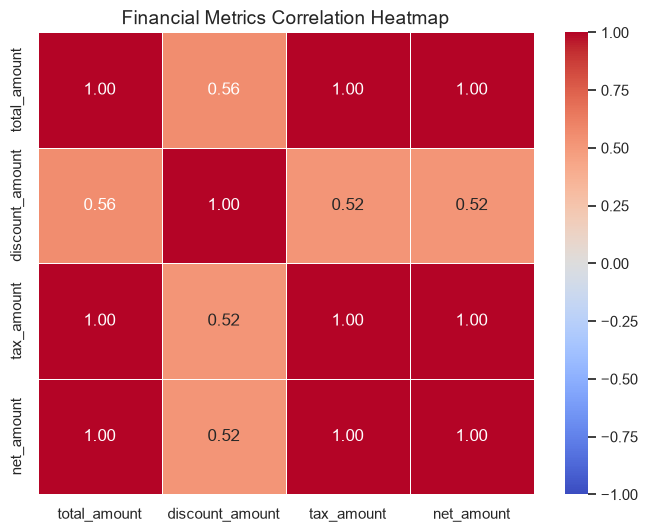

In [5]:
if orders_df is not None:
    print("--- CORRELATION MATRIX (PEARSON) ---")
    # Select numerical values
    financial_vars = ["total_amount", "discount_amount", "tax_amount", "net_amount"]
    correlation_matrix = orders_df[financial_vars].corr()
    display(correlation_matrix)
    
    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(data=correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title("Financial Metrics Correlation Heatmap", fontsize=14)
    plt.show()
else:
    print("Core orders dataset not found.")

### 6. Detecting Outliers
Placeholder for detecting outliers steps.

In [6]:
if orders_df is not None:
    print("--- OUTLIER DETECTION (IQR METHOD) ---")
    # Calculate boundaries using Interquartile Range on net_amount
    q1 = orders_df["net_amount"].quantile(0.25)
    q3 = orders_df["net_amount"].quantile(0.75)
    iqr = q3 - q1
    
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    print(f"Q1 (25th percentile): {q1:,.2f}")
    print(f"Q3 (75th percentile): {q3:,.2f}")
    print(f"IQR (Spread): {iqr:,.2f}")
    print(f"Lower Outlier Limit: {lower_limit:,.2f}")
    print(f"Upper Outlier Limit: {upper_limit:,.2f}\n")
    
    # Query outlier rows
    outliers = orders_df[(orders_df["net_amount"] < lower_limit) | (orders_df["net_amount"] > upper_limit)]
    print(f"Total Outlier Records: {len(outliers)} (out of {len(orders_df)} total - {len(outliers)/len(orders_df)*100:.2f}%)")
    
    if not outliers.empty:
        print("\nSample of Outlier Transactions (Highest/Lowest values):")
        display(outliers[["order_id", "order_number", "net_amount", "payment_mode", "finance_provider"]].head(10))
        
        # Box plot visualizing the outliers
        plt.figure(figsize=(6, 8))
        sns.boxplot(data=orders_df, y="net_amount", color="lightblue")
        plt.title("Box Plot of Sales Net Amount (Showing Outliers)", fontsize=14)
        plt.ylabel("Net Amount ($)", fontsize=12)
        plt.show()
else:
    print("Core orders dataset not found.")

--- OUTLIER DETECTION (IQR METHOD) ---
Q1 (25th percentile): 1,142,882.15
Q3 (75th percentile): 2,436,841.56
IQR (Spread): 1,293,959.41
Lower Outlier Limit: -798,056.97
Upper Outlier Limit: 4,377,780.68

Total Outlier Records: 0 (out of 7000 total - 0.00%)
